##### This project is part of day 99 from the "100 days of code Python pro bootcamp with Dr. Angela Yu"
# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [2]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [5]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [6]:
df_data.shape
print("There are {} rows and {} columns in the dataset".format(df_data.shape[0], df_data.shape[1]))

There are 7095 rows and 8 columns in the dataset


In [7]:
df_data.head()

,Unnamed: 0,Organisation,Location,Datetime,Details,Status,Price,Mission_status
0,0,SpaceX,"SLC-4E, Vandenberg SFB, California, USA","Tue Jun 17, 2025 03:36 UTC",Falcon 9 Block 5 | Starlink Group 15-9,Active,69.75,Success
1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Sat Jun 14, 2025 07:56 UTC",Long March 2D | Zhangheng-1-02,Active,29.75,Success
2,2,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Fri Jun 13, 2025 15:29 UTC",Falcon 9 Block 5 | Starlink Group 12-26,Active,69.75,Success
3,3,SpaceX,"SLC-4E, Vandenberg SFB, California, USA","Fri Jun 13, 2025 01:54 UTC",Falcon 9 Block 5 | Starlink Group 15-6,Active,69.75,Success
4,4,Rocket Lab,"Rocket Lab LC-1A, Māhia Peninsula, New Zealand","Wed Jun 11, 2025 15:31 UTC",Electron/Curie | The Mountain God Guards,Active,7.50,Success


In [8]:
df_data.isna().sum()

Unnamed: 0           0
Organisation         0
Location             0
Datetime             0
Details              0
Status               0
Price             4137
Mission_status       0
dtype: int64

In [9]:
print(f'Any duplicates? {df_data.duplicated().values.any()}')

Any duplicates? False


In [10]:
print(f'Any NaN values among the data? {df_data.isna().values.any()}')


Any NaN values among the data? True


In [11]:
df_data.isna().sum()

Unnamed: 0           0
Organisation         0
Location             0
Datetime             0
Details              0
Status               0
Price             4137
Mission_status       0
dtype: int64

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [12]:
col_subset = ['Price']
df_data.loc[df_data.Price.isna()][col_subset]

,Price
8,NaN
13,NaN
18,NaN
23,NaN
25,NaN
...,...
7090,NaN
7091,NaN
7092,NaN
7093,NaN


In [13]:
df_data["Price"] = pd.to_numeric(df_data["Price"], errors="coerce")


In [14]:
df_cleaned = df_data.drop_duplicates().dropna()

In [15]:
df_cleaned.head()


,Unnamed: 0,Organisation,Location,Datetime,Details,Status,Price,Mission_status
0,0,SpaceX,"SLC-4E, Vandenberg SFB, California, USA","Tue Jun 17, 2025 03:36 UTC",Falcon 9 Block 5 | Starlink Group 15-9,Active,69.75,Success
1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Sat Jun 14, 2025 07:56 UTC",Long March 2D | Zhangheng-1-02,Active,29.75,Success
2,2,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Fri Jun 13, 2025 15:29 UTC",Falcon 9 Block 5 | Starlink Group 12-26,Active,69.75,Success
3,3,SpaceX,"SLC-4E, Vandenberg SFB, California, USA","Fri Jun 13, 2025 01:54 UTC",Falcon 9 Block 5 | Starlink Group 15-6,Active,69.75,Success
4,4,Rocket Lab,"Rocket Lab LC-1A, Māhia Peninsula, New Zealand","Wed Jun 11, 2025 15:31 UTC",Electron/Curie | The Mountain God Guards,Active,7.50,Success


In [16]:
df_cleaned.shape

(2958, 8)

## Descriptive Statistics

In [17]:
df_cleaned.describe()

,Unnamed: 0,Price
count,"2,958.00","2,958.00"
mean,"2,148.41",67.82
std,"1,540.35",96.42
min,0.00,2.50
25%,885.25,20.00
50%,"1,779.50",30.80
75%,"3,385.75",69.75
max,"6,725.00",876.00


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

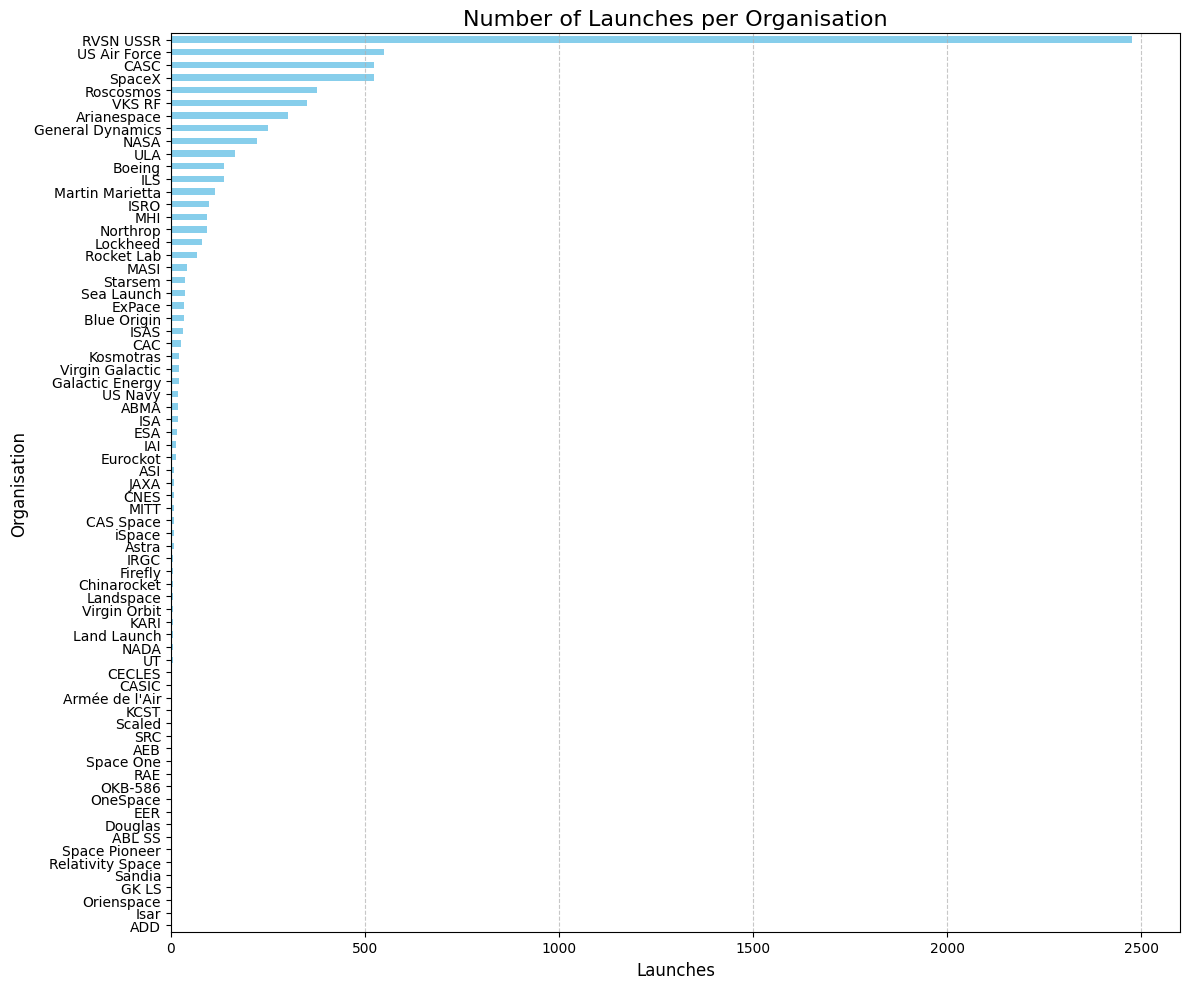

In [18]:
launch_counts = df_data['Organisation'].value_counts().sort_values(ascending=True)

# Criar o gráfico de barras
plt.figure(figsize=(12, 10))
launch_counts.plot(kind='barh', color='skyblue')
plt.title('Number of Launches per Organisation', fontsize=16)
plt.xlabel('Launches', fontsize=12)
plt.ylabel('Organisation', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [38]:
print(df_data.columns)

Index(['Unnamed: 0', 'Organisation', 'Location', 'Datetime', 'Details',
       'Status', 'Price', 'Mission_status', 'Datetime_parsed', 'Year'],
      dtype='object')


In [39]:
status_counts = df_data['Mission_status'].value_counts()
print(status_counts)

Mission_status
Success              6502
Failure               467
Partial Failure       117
Prelaunch Failure       9
Name: count, dtype: int64


# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
mission_counts = df_data['Mission_Status'].value_counts()
print(mission_counts)

Mission_Status
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64


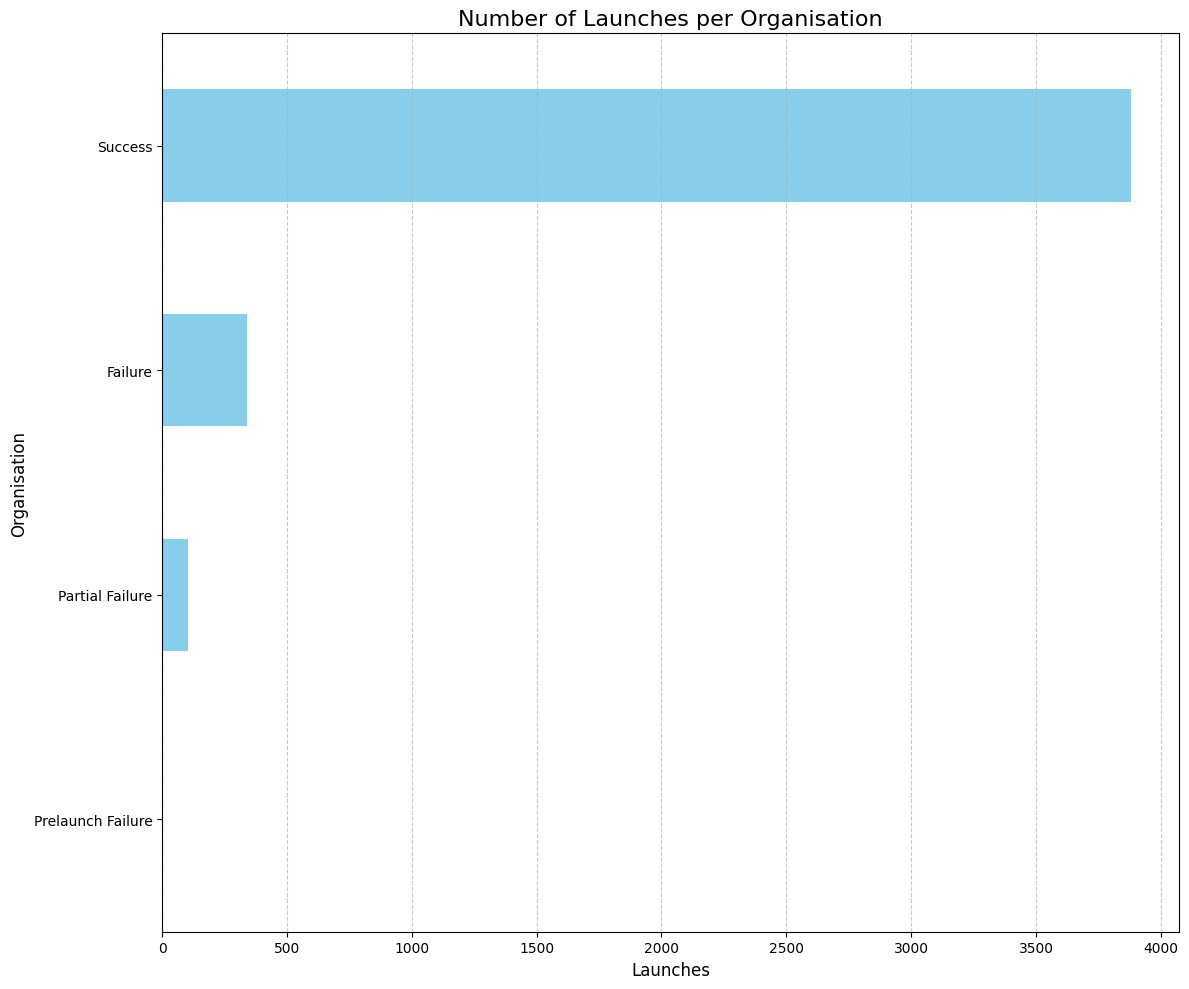

In [ ]:
mission_counts = df_data['Mission_Status'].value_counts().sort_values(ascending=True)

# plot the chart
plt.figure(figsize=(12, 10))
mission_counts.plot(kind='barh', color='skyblue')
plt.title('Number of Launches per Organisation', fontsize=16)
plt.xlabel('Launches', fontsize=12)
plt.ylabel('Organisation', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

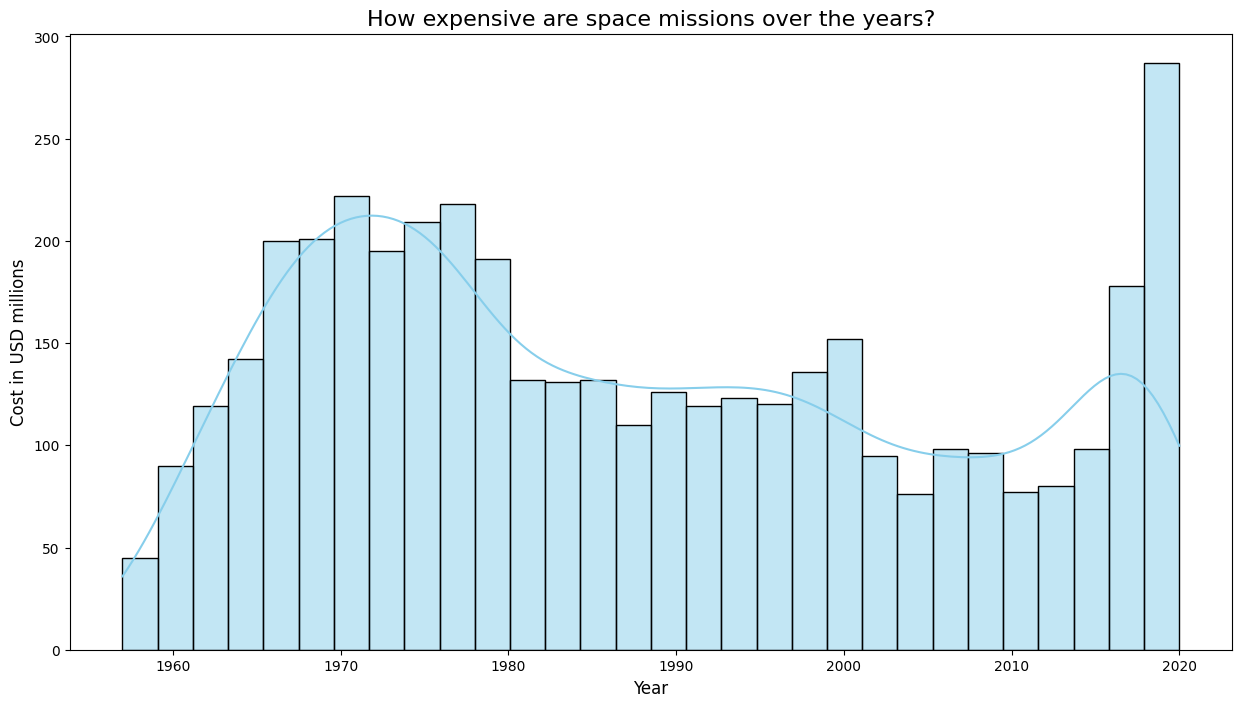

In [ ]:
# Extract launch year from the Date column
df_data['Price'] = pd.to_datetime(df_data['Date'], errors='coerce').dt.year

plt.figure(figsize=(15, 8))
sns.histplot(data=df_data, x='Price', bins=30, kde=True, color='skyblue')
plt.title('How expensive are space missions over the years?', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cost in USD millions', fontsize=12)
plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
# Extract country from Location, apply replacements, convert to ISO Alpha-3, and plot launches by country
import re
from iso3166 import countries
country_replacements = {
    'Russia': 'Russian Federation',
    'New Mexico': 'USA',
    'Yellow Sea': 'China',
    'Shahrud Missile Test Site': 'Iran',
    'Pacific Missile Range Facility': 'USA',
    'Barents Sea': 'Russian Federation',
    'Gran Canaria': 'USA'
}
def extract_country(location):
    # Try to extract the last part after comma, or use full string if no comma
    if pd.isna(location):
        return None
    parts = [p.strip() for p in location.split(',')]
    if parts:
        country = parts[-1]
        # Apply replacements if needed
        return country_replacements.get(country, country)
    return None
df_data['Country_Clean'] = df_data['Location'].apply(extract_country)
# Function to convert country names to ISO Alpha-3 codes
def get_alpha3(country_name):
    try:
        return countries.get(country_name).alpha3
    except Exception:
        return None
# Map cleaned country names to ISO Alpha-3 codes
df_data['Country_Code'] = df_data['Country_Clean'].apply(get_alpha3)
launches_by_country = df_data['Country_Code'].value_counts().reset_index()
launches_by_country.columns = ['Country_Code', 'Launch_Count']
# Plotting the choropleth map
fig = px.choropleth(
    launches_by_country,
    locations='Country_Code',
    color='Launch_Count',
    hover_name='Country_Code',
    color_continuous_scale=px.colors.sequential.matter,
    title='Number of Launches by Country'
 )
fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
# Choropleth map: Number of mission failures by country
failures = df_data[df_data['Mission_Status'].str.lower().str.contains('fail')]
failures_by_country = failures['Country_Code'].value_counts().reset_index()
failures_by_country.columns = ['Country_Code', 'Failure_Count']
fig = px.choropleth(
    failures_by_country,
    locations='Country_Code',
    color='Failure_Count',
    hover_name='Country_Code',
    color_continuous_scale=px.colors.sequential.matter,
    title='Number of Mission Failures by Country'
 )
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [ ]:
# Prepare data for sunburst chart
sunburst_df = df_data[['Country_Clean', 'Organisation', 'Mission_Status']].copy()

# Remove any rows with missing values
sunburst_df = sunburst_df.dropna()

# Create a new DataFrame with value counts for each combination
grouped = sunburst_df.groupby(['Country_Clean', 'Organisation', 'Mission_Status']).size().reset_index(name='count')

# Create the sunburst chart
fig = px.sunburst(
    grouped,
    path=['Country_Clean', 'Organisation', 'Mission_Status'],
    values='count',
    title='Space Missions Hierarchy: Countries → Organizations → Mission Status'
)

# Update layout
fig.update_layout(width=800, height=800)

fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

C:\Users\lucas\AppData\Local\Temp\ipykernel_39852\2539288811.py:20: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



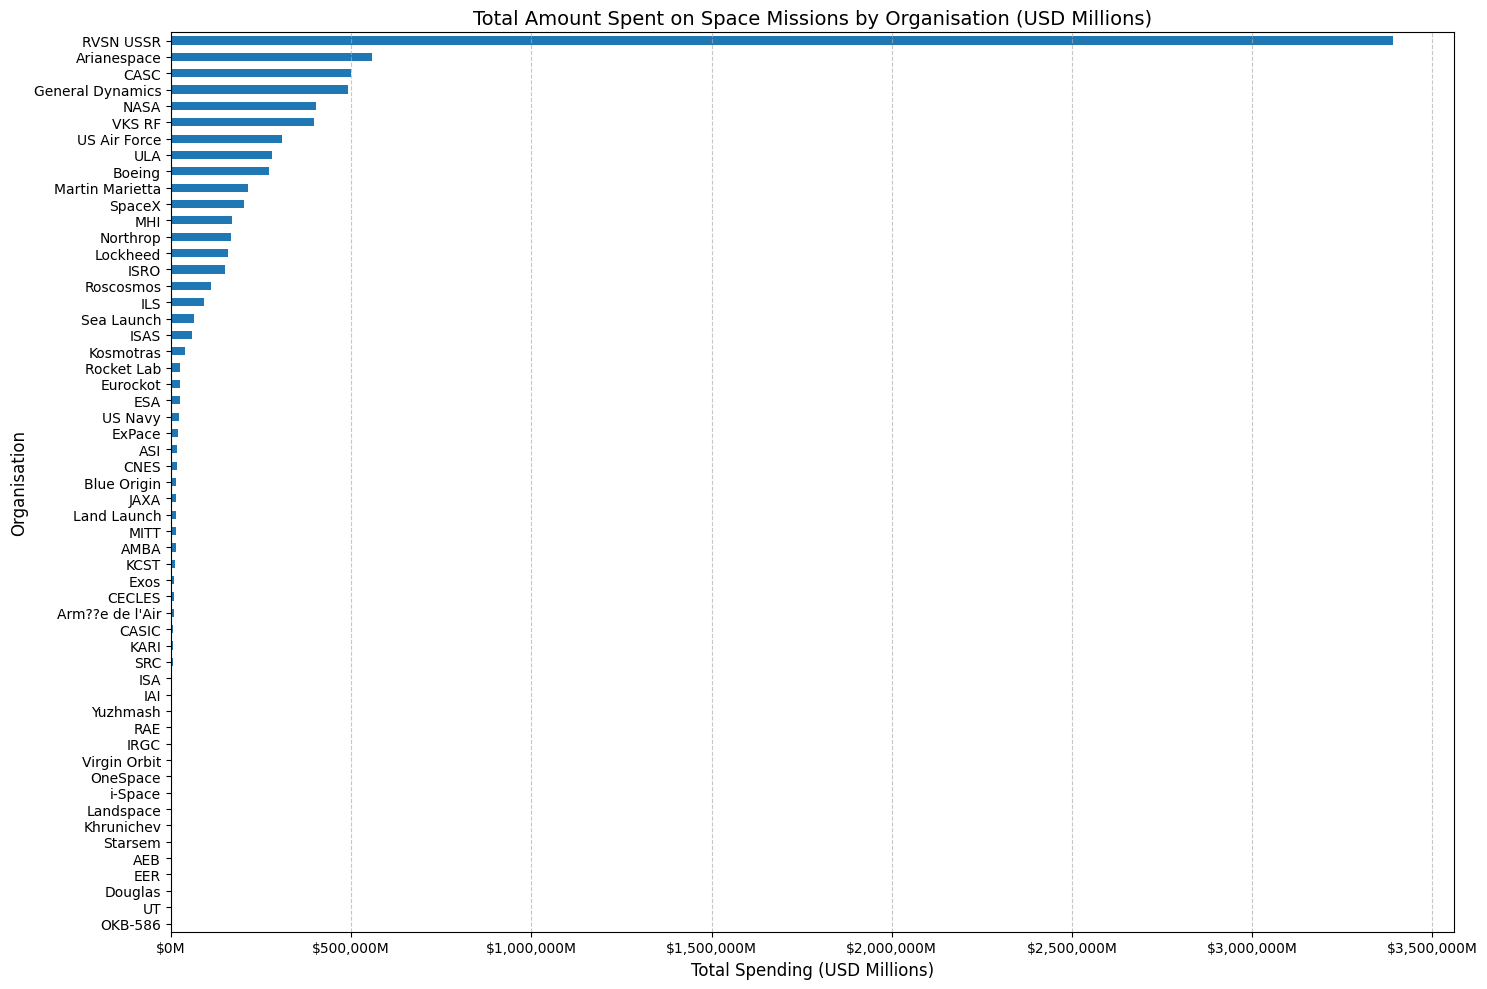


Top 5 Organizations by Total Spending:
NASA: $403,018.00 million
General Dynamics: $491,125.00 million
CASC: $499,694.00 million
Arianespace: $558,978.00 million
RVSN USSR: $3,391,453.00 million


In [ ]:
# Get total spending by organization
# First ensure Price column contains numeric values
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')

# Group by organization and sum the prices
org_spending = df_data.groupby('Organisation')['Price'].sum().sort_values(ascending=True)

# Filter out organizations with no spending data
org_spending = org_spending[org_spending > 0]

# Create a bar chart of total spending by organization
plt.figure(figsize=(15, 10))
org_spending.plot(kind='barh')
plt.title('Total Amount Spent on Space Missions by Organisation (USD Millions)', fontsize=14)
plt.xlabel('Total Spending (USD Millions)', fontsize=12)
plt.ylabel('Organisation', fontsize=12)

# Format x-axis labels to show billions/millions properly
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['${:,.0f}M'.format(x) for x in current_values])

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print top 5 organizations by spending
print("\nTop 5 Organizations by Total Spending:")
top_5_spending = org_spending.tail(5)
for org, spent in top_5_spending.items():
    print(f"{org}: ${spent:,.2f} million")

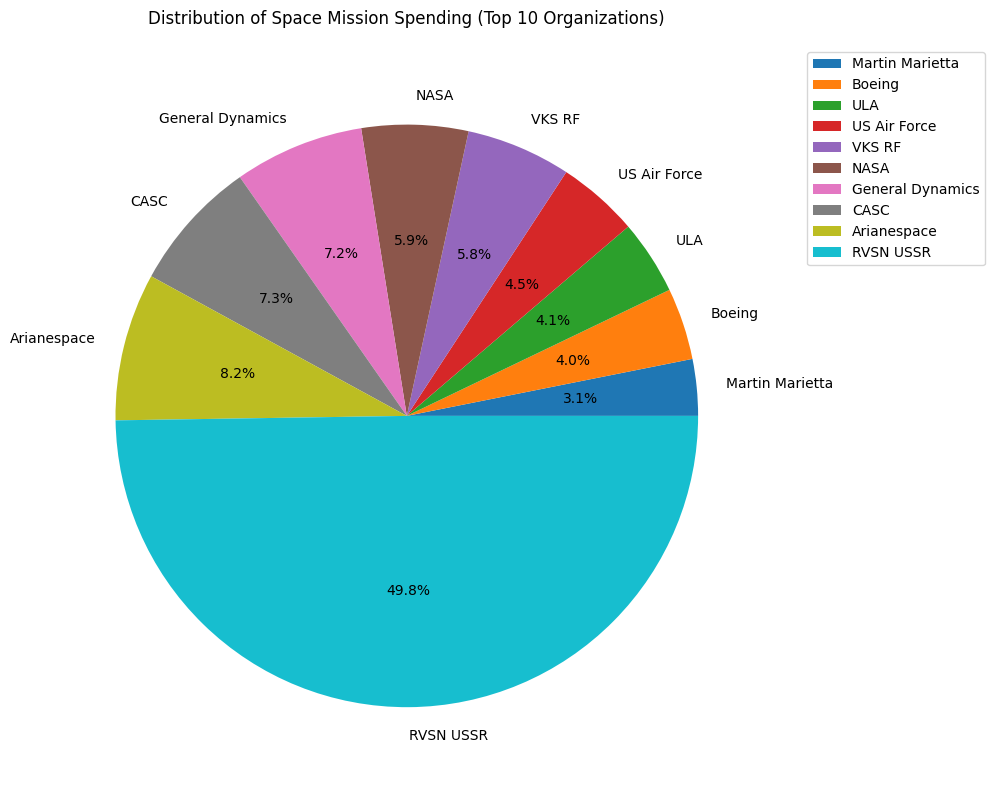


Total spending across all organizations: $8,343,339.00 million
Average spending per organization: $151,697.07 million
Median spending per organization: $14,125.00 million


In [ ]:
# Create a pie chart of the top 10 organizations by spending
top_10_spending = org_spending.tail(10)

plt.figure(figsize=(12, 8))
plt.pie(top_10_spending.values, labels=top_10_spending.index, autopct='%1.1f%%')
plt.title('Distribution of Space Mission Spending (Top 10 Organizations)', pad=20)

# Add a legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

# Calculate and print some statistics
total_spending = org_spending.sum()
print(f"\nTotal spending across all organizations: ${total_spending:,.2f} million")
print(f"Average spending per organization: ${org_spending.mean():,.2f} million")
print(f"Median spending per organization: ${org_spending.median():,.2f} million")

# Analyse the Amount of Money Spent by Organisation per Launch

C:\Users\lucas\AppData\Local\Temp\ipykernel_39852\669864806.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



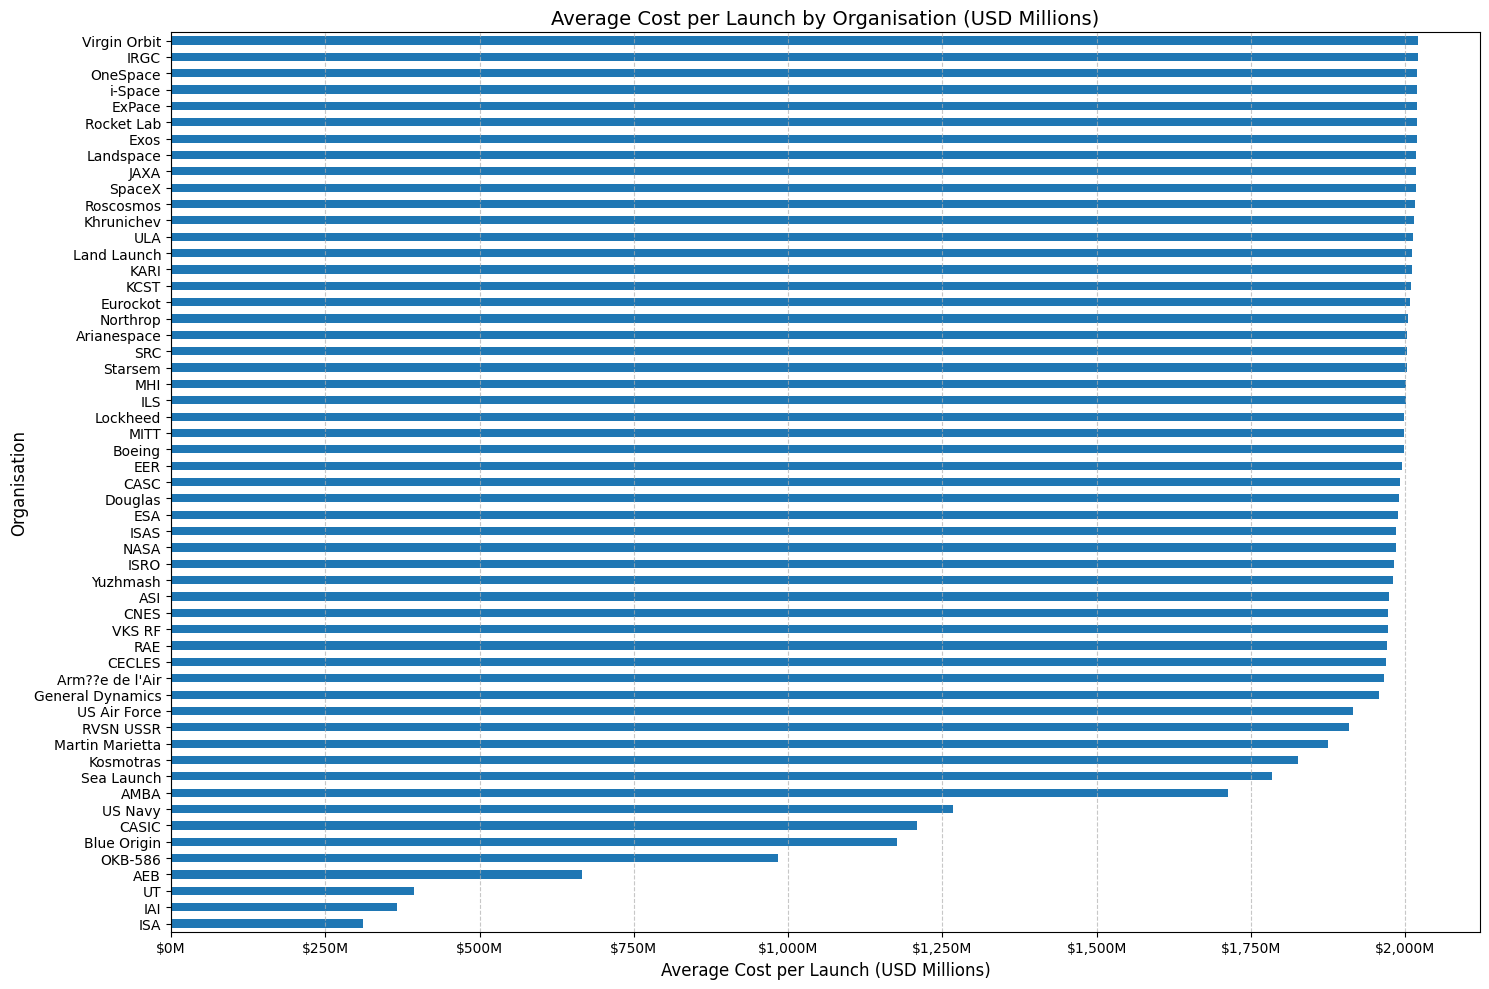


Top 5 Organizations by Average Cost per Launch:
ExPace:
  Average cost per launch: $2,019.00 million
  Number of launches: 10
  Total spent: $20,190.00 million

i-Space:
  Average cost per launch: $2,019.00 million
  Number of launches: 1
  Total spent: $2,019.00 million

OneSpace:
  Average cost per launch: $2,019.00 million
  Number of launches: 1
  Total spent: $2,019.00 million

IRGC:
  Average cost per launch: $2,020.00 million
  Number of launches: 1
  Total spent: $2,020.00 million

Virgin Orbit:
  Average cost per launch: $2,020.00 million
  Number of launches: 1
  Total spent: $2,020.00 million



In [ ]:
# Calculate spending per launch for each organization
# First ensure Price column contains numeric values
df_data['Price'] = pd.to_numeric(df_data['Price'], errors='coerce')

# Calculate mean price per launch for each organization
launches_per_org = df_data.groupby('Organisation').size()
total_spending_per_org = df_data.groupby('Organisation')['Price'].sum()
avg_cost_per_launch = (total_spending_per_org / launches_per_org).sort_values(ascending=True)

# Remove organizations with no cost data
avg_cost_per_launch = avg_cost_per_launch[avg_cost_per_launch > 0]

# Create bar chart
plt.figure(figsize=(15, 10))
avg_cost_per_launch.plot(kind='barh')
plt.title('Average Cost per Launch by Organisation (USD Millions)', fontsize=14)
plt.xlabel('Average Cost per Launch (USD Millions)', fontsize=12)
plt.ylabel('Organisation', fontsize=12)

# Format x-axis labels
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['${:,.0f}M'.format(x) for x in current_values])

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print statistics for top 5 most expensive per launch
print("\nTop 5 Organizations by Average Cost per Launch:")
top_5_expensive = avg_cost_per_launch.tail(5)
for org, cost in top_5_expensive.items():
    num_launches = launches_per_org[org]
    total_spent = total_spending_per_org[org]
    print(f"{org}:")
    print(f"  Average cost per launch: ${cost:,.2f} million")
    print(f"  Number of launches: {num_launches}")
    print(f"  Total spent: ${total_spent:,.2f} million\n")

In [ ]:
# Create a scatter plot of number of launches vs average cost
plt.figure(figsize=(12, 8))
plt.scatter(launches_per_org[avg_cost_per_launch.index], 
            avg_cost_per_launch, 
            alpha=0.6)

# Add organization labels for points with high costs or many launches
for org in avg_cost_per_launch.index:
    launches = launches_per_org[org]
    cost = avg_cost_per_launch[org]
    if launches > 50 or cost > 200:  # Adjust these thresholds as needed
        plt.annotate(org, (launches, cost), 
                     xytext=(5, 5), textcoords='offset points')

plt.title('Number of Launches vs Average Cost per Launch by Organisation', fontsize=14)
plt.xlabel('Number of Launches', fontsize=12)
plt.ylabel('Average Cost per Launch (USD Millions)', fontsize=12)

# Format y-axis labels
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}M'.format(x) for x in current_values])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = np.corrcoef(launches_per_org[avg_cost_per_launch.index], avg_cost_per_launch)[0,1]
print(f"\nCorrelation between number of launches and average cost: {correlation:.2f}")

# Print some interesting statistics
print("\nOrganizations with most cost-effective launches (minimum average cost):")
print(avg_cost_per_launch.head().to_frame('Avg Cost (USD M)').join(
      launches_per_org.to_frame('Number of Launches')))

# Chart the Number of Launches per Year

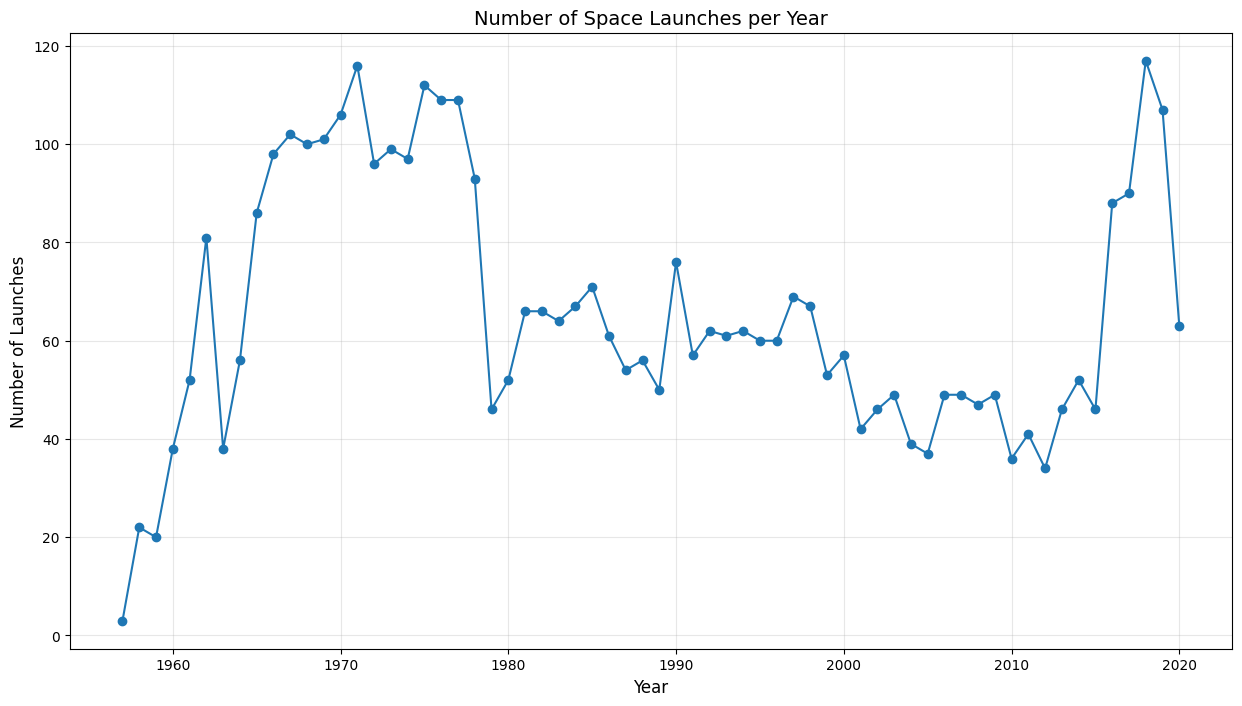

Year with most launches: 2018.0 (117 launches)


In [ ]:
# Convert dates and count launches per year
df_data['Launch_Year'] = pd.to_datetime(df_data['Date'], errors='coerce').dt.year
launches_per_year = df_data['Launch_Year'].value_counts().sort_index()

# Create line plot
plt.figure(figsize=(15, 8))
plt.plot(launches_per_year.index, launches_per_year.values, marker='o')

plt.title('Number of Space Launches per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Print peak year
peak_year = launches_per_year.idxmax()
print(f"Year with most launches: {peak_year} ({launches_per_year[peak_year]} launches)")

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

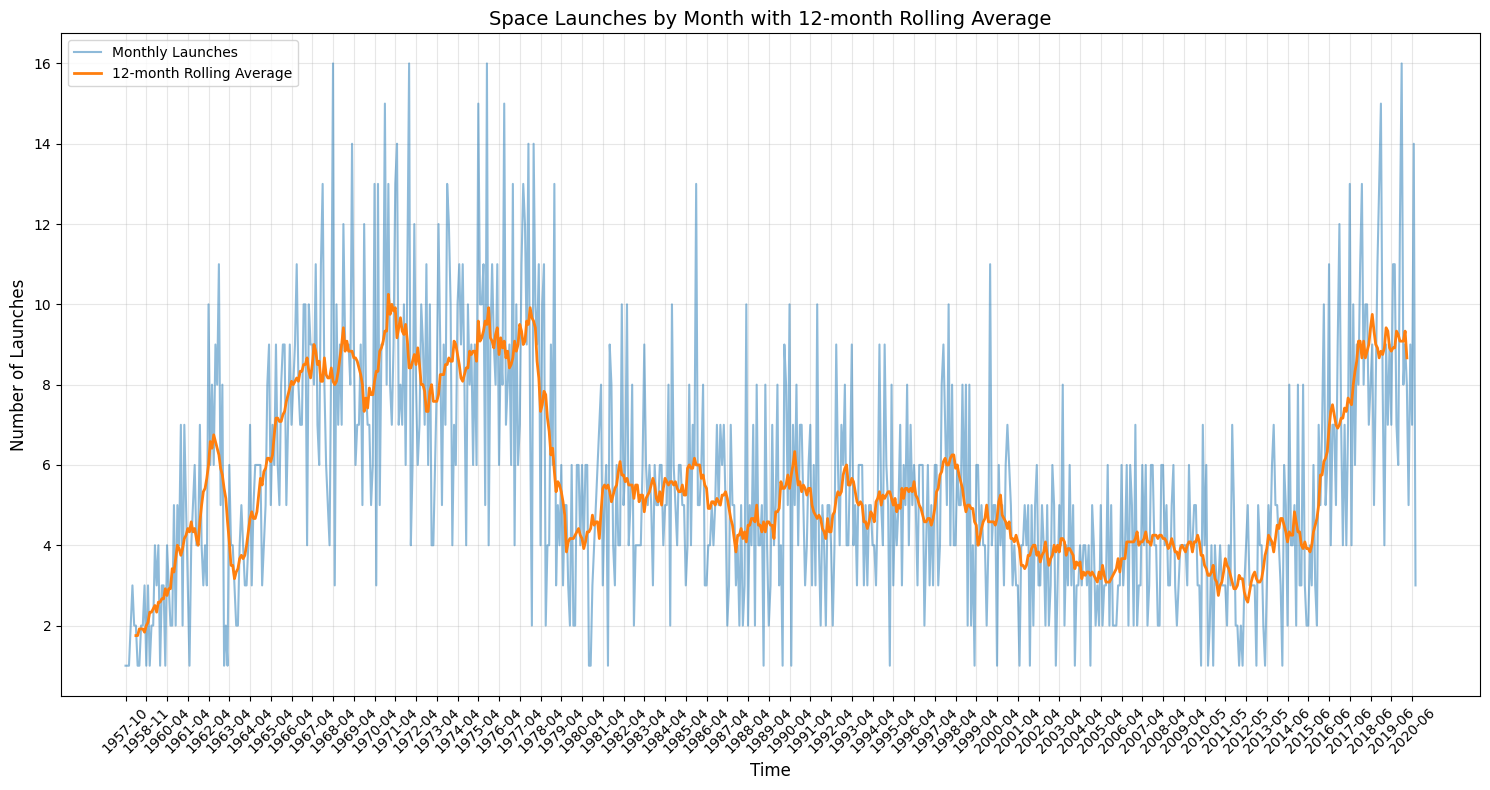

Month with most launches: 1968-04 (16 launches)


In [ ]:
# Convert dates to datetime and create monthly counts
df_data['Date'] = pd.to_datetime(df_data['Date'], errors='coerce')
monthly_launches = df_data.groupby(df_data['Date'].dt.strftime('%Y-%m')).size()

# Calculate 12-month rolling average
rolling_avg = monthly_launches.rolling(window=12, center=True).mean()

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(range(len(monthly_launches)), monthly_launches.values, alpha=0.5, label='Monthly Launches')
plt.plot(range(len(rolling_avg)), rolling_avg.values, linewidth=2, label='12-month Rolling Average')

# Customize the plot
plt.title('Space Launches by Month with 12-month Rolling Average', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(True, alpha=0.3)

# Set x-axis ticks to show years
tick_positions = np.arange(0, len(monthly_launches), 12)  # Every 12 months
tick_labels = [monthly_launches.index[i] for i in tick_positions if i < len(monthly_launches)]
plt.xticks(tick_positions, tick_labels, rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

# Find month with highest launches
peak_month = monthly_launches.idxmax()
peak_launches = monthly_launches.max()
print(f"Month with most launches: {peak_month} ({peak_launches} launches)")

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

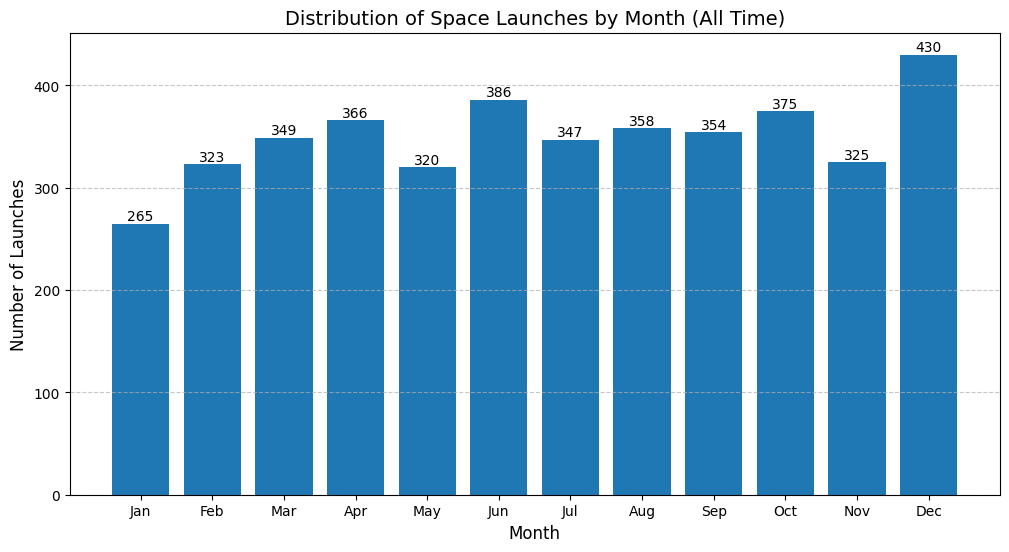


Top 3 Most Popular Months for Launches:
Dec: 430 launches
Jun: 386 launches
Oct: 375 launches

Least Popular Months for Launches:
Jan: 265 launches
May: 320 launches
Feb: 323 launches


In [ ]:
# Extract month from dates and count launches per month
monthly_distribution = df_data['Date'].dt.month.value_counts().sort_index()

# Create bar plot
plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_distribution.index, monthly_distribution.values)

# Add labels and title
plt.title('Distribution of Space Launches by Month (All Time)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)

# Format x-axis to show month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(monthly_distribution.index, month_names)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print statistics
print("\nTop 3 Most Popular Months for Launches:")
top_months = monthly_distribution.nlargest(3)
for month, launches in top_months.items():
    print(f"{month_names[int(month)-1]}: {launches} launches")

print("\nLeast Popular Months for Launches:")
bottom_months = monthly_distribution.nsmallest(3)
for month, launches in bottom_months.items():
    print(f"{month_names[int(month)-1]}: {launches} launches")

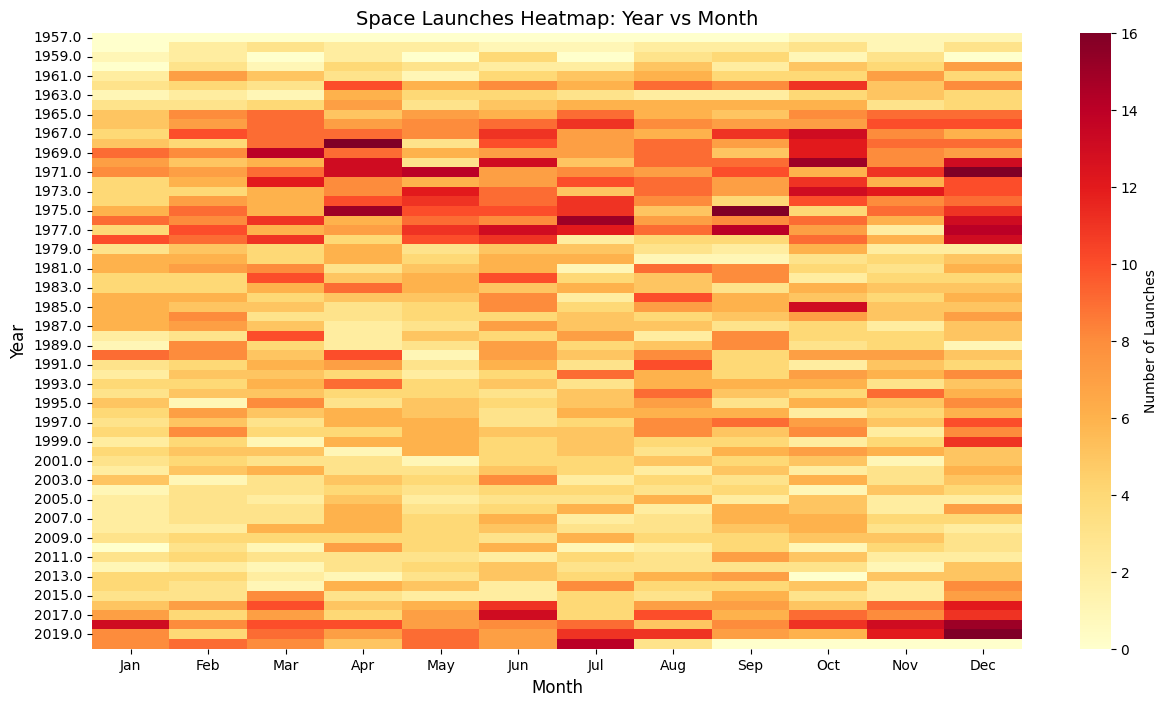


Average Number of Launches per Month by Decade:
        Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
Decade                                                            
1950s     1    7    4    8    5    7    3   10    8   10    9   11
1960s    44   58   69   85   49   77   66   70   64   92   72   74
1970s    58   71   75   83   90   85   85   62   73   78   66  103
1980s    50   60   60   44   42   66   43   60   59   55   43   49
1990s    34   48   48   50   47   41   50   67   52   51   49   71
2000s    22   31   34   49   32   48   35   34   43   42   32   41
2010s    56   48   59   47   55   62   65   55   55   47   54   81
2020s     0    0    0    0    0    0    0    0    0    0    0    0


C:\Users\lucas\AppData\Local\Temp\ipykernel_39852\2680332008.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# Create a heatmap showing launches by month and year
launches_by_month_year = df_data.pivot_table(
    index=df_data['Date'].dt.year,
    columns=df_data['Date'].dt.month,
    aggfunc='size',
    fill_value=0
)

# Set column names to month abbreviations
launches_by_month_year.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(15, 8))
sns.heatmap(launches_by_month_year, 
            cmap='YlOrRd',
            cbar_kws={'label': 'Number of Launches'},
            fmt='d')

plt.title('Space Launches Heatmap: Year vs Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.show()

# Calculate average launches per month in different decades
decades = pd.cut(df_data['Date'].dt.year, 
                bins=range(1950, 2031, 10),
                labels=[f'{i}s' for i in range(1950, 2021, 10)])
df_data['Decade'] = decades

decade_month_avg = df_data.groupby(['Decade', df_data['Date'].dt.month]).size().unstack()
decade_month_avg.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("\nAverage Number of Launches per Month by Decade:")
print(decade_month_avg.round(1))

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

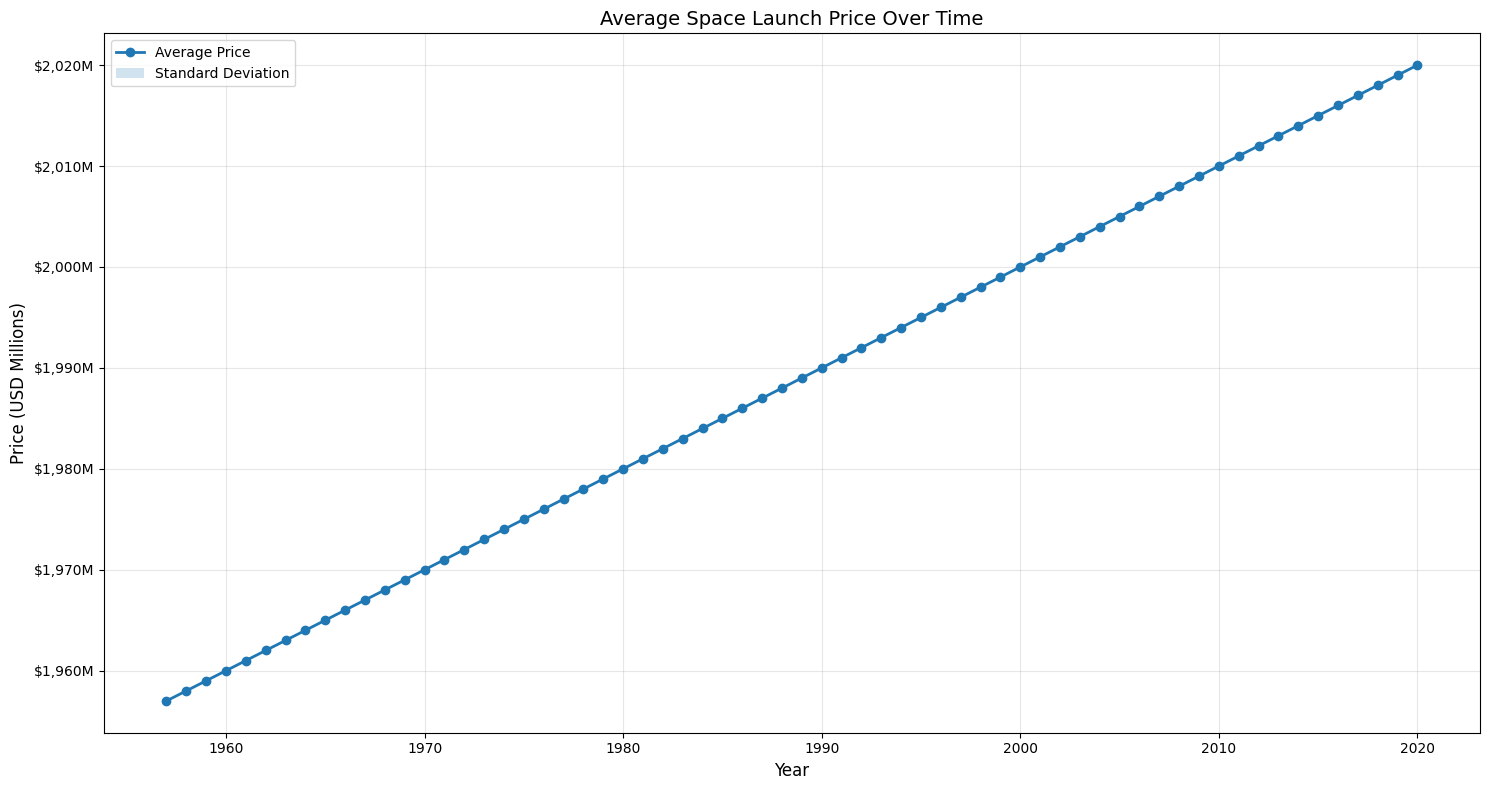


Price Analysis:
Most expensive year on average: 2020.0 ($2,020.00M)
Least expensive year on average: 1957.0 ($1,957.00M)

Trend Analysis:
Average annual change in price: $1.00M per year
R-squared value: 1.000

Trend Analysis:
Average annual change in price: $1.00M per year
R-squared value: 1.000


In [ ]:
# Calculate average price per year
yearly_prices = df_data.groupby('Launch_Year')['Price'].agg(['mean', 'count', 'std']).reset_index()
yearly_prices = yearly_prices[yearly_prices['count'] > 2]  # Filter years with too few launches

# Create the line plot
plt.figure(figsize=(15, 8))

# Plot average price line
plt.plot(yearly_prices['Launch_Year'], yearly_prices['mean'], 
         marker='o', linewidth=2, label='Average Price')

# Add confidence interval
plt.fill_between(yearly_prices['Launch_Year'],
                 yearly_prices['mean'] - yearly_prices['std'],
                 yearly_prices['mean'] + yearly_prices['std'],
                 alpha=0.2, label='Standard Deviation')

# Customize the plot
plt.title('Average Space Launch Price Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD Millions)', fontsize=12)
plt.grid(True, alpha=0.3)

# Format y-axis to show millions
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}M'))

plt.legend()
plt.tight_layout()
plt.show()

# Print some statistics
print("\nPrice Analysis:")
print(f"Most expensive year on average: {yearly_prices.loc[yearly_prices['mean'].idxmax(), 'Launch_Year']} " + 
      f"(${yearly_prices['mean'].max():,.2f}M)")
print(f"Least expensive year on average: {yearly_prices.loc[yearly_prices['mean'].idxmin(), 'Launch_Year']} " + 
      f"(${yearly_prices['mean'].min():,.2f}M)")

# Calculate overall trend
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_prices['Launch_Year'], 
                                                              yearly_prices['mean'])
print(f"\nTrend Analysis:")
print(f"Average annual change in price: ${slope:,.2f}M per year")
print(f"R-squared value: {r_value**2:.3f}")

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

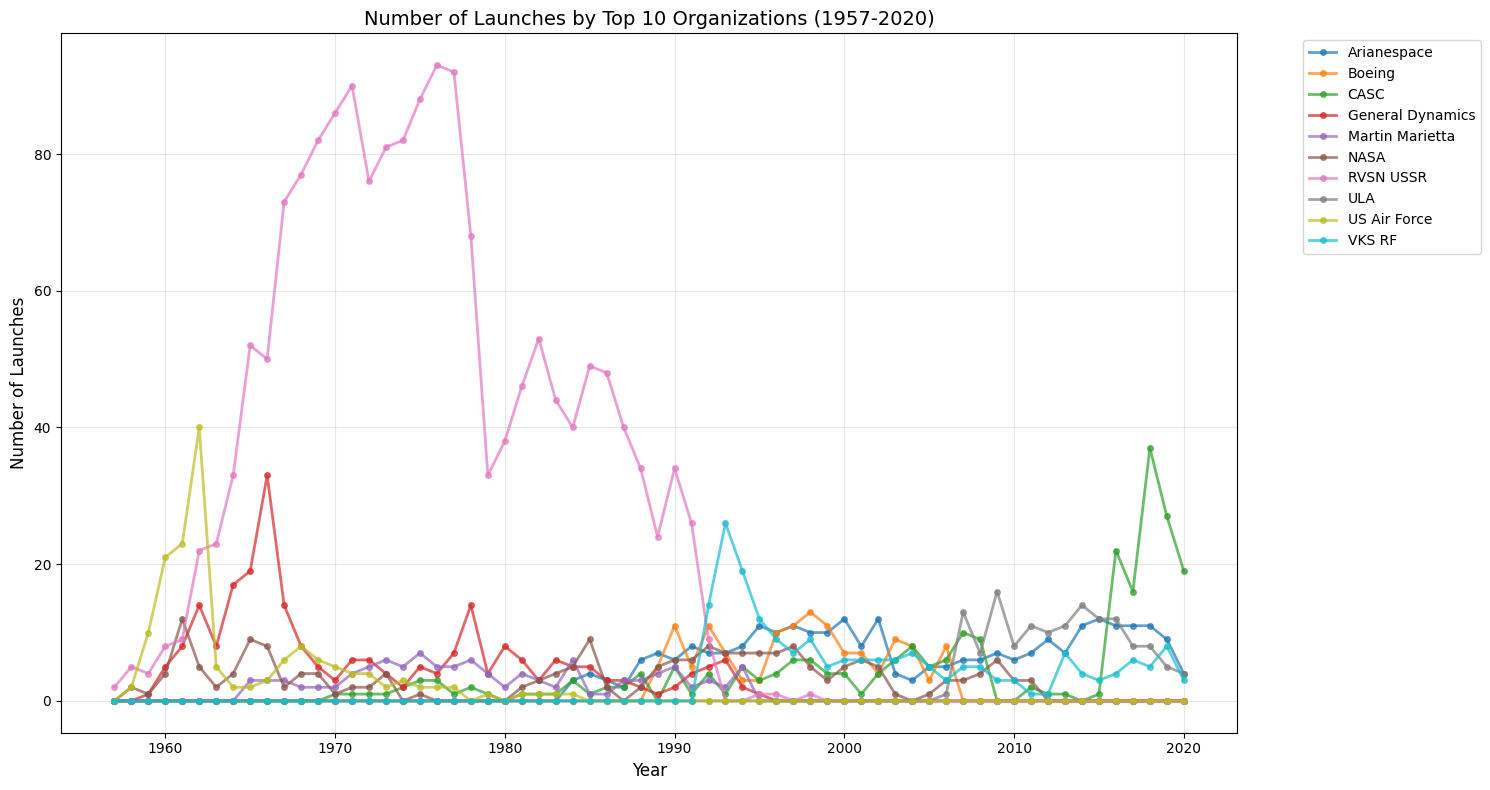


Dominant organizations by decade:
1960s: RVSN USSR (429 launches)
1970s: RVSN USSR (789 launches)
1980s: RVSN USSR (416 launches)
1990s: VKS RF (101 launches)
2000s: Arianespace (68 launches)
2010s: CASC (107 launches)
2020s: CASC (19 launches)


In [ ]:
# Get the top 10 organizations by total launches
top_10_orgs = df_data['Organisation'].value_counts().nlargest(10).index

# Create a DataFrame with just the data we need
launch_data = df_data[df_data['Organisation'].isin(top_10_orgs)].copy()
launch_data['Year'] = pd.to_datetime(launch_data['Date']).dt.year

# Create pivot table for launches by year and organization
launches_by_year = pd.pivot_table(
    data=launch_data,
    index='Year',
    columns='Organisation',
    aggfunc='size',
    fill_value=0
)

# Create the plot
plt.figure(figsize=(15, 8))

# Plot each organization's launches
for org in launches_by_year.columns:
    plt.plot(launches_by_year.index, launches_by_year[org], 
            marker='o', markersize=4, label=org, linewidth=2, alpha=0.7)

plt.title('Number of Launches by Top 10 Organizations (1957-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDominant organizations by decade:")
for decade in range(1960, 2021, 10):
    decade_data = launches_by_year.loc[decade:decade+9].sum()
    top_org = decade_data.idxmax()
    launches = decade_data.max()
    print(f"{decade}s: {top_org} ({launches:.0f} launches)")

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [ ]:
# Define countries in each group
soviet_bloc = ['Russian Federation', 'Kazakhstan', 'Ukraine']  # Soviet/Post-Soviet countries
usa = ['USA']

# Function to categorize countries
def categorize_country(country):
    if country in soviet_bloc:
        return 'USSR/Soviet Bloc'
    elif country in usa:
        return 'USA'
    else:
        return 'Other'

# Create a new column with the categorized countries
df_data['Superpower'] = df_data['Country_Clean'].apply(categorize_country)

# Count launches for each superpower
superpower_launches = df_data['Superpower'].value_counts()
superpower_launches = superpower_launches[superpower_launches.index.isin(['USSR/Soviet Bloc', 'USA'])]

# Create pie chart using plotly
fig = px.pie(
    values=superpower_launches.values,
    names=superpower_launches.index,
    title='Space Race: Total Number of Launches - USA vs USSR/Soviet Bloc',
    color_discrete_sequence=['#DE1738', '#002868'],  # Soviet red and American blue
    hole=0.3
)

# Update layout
fig.update_layout(
    title_x=0.5,
    annotations=[
        dict(
            text=f'Total Launches:<br>{superpower_launches.sum():,}',
            showarrow=False,
            font_size=14
        )
    ]
)

fig.show()

# Print detailed statistics
print("\nDetailed Launch Statistics:")
for power in ['USSR/Soviet Bloc', 'USA']:
    launches = superpower_launches[power]
    percentage = (launches / superpower_launches.sum()) * 100
    print(f"{power}: {launches:,} launches ({percentage:.1f}%)")

# Show contribution of individual Soviet/Post-Soviet states
print("\nBreakdown of Soviet Bloc launches:")
soviet_breakdown = df_data[df_data['Country_Clean'].isin(soviet_bloc)]['Country_Clean'].value_counts()
for country, launches in soviet_breakdown.items():
    percentage = (launches / soviet_breakdown.sum()) * 100
    print(f"{country}: {launches:,} launches ({percentage:.1f}%)")


Detailed Launch Statistics:
USSR/Soviet Bloc: 2,099 launches (60.8%)
USA: 1,351 launches (39.2%)

Breakdown of Soviet Bloc launches:
Russian Federation: 1,398 launches (66.6%)
Kazakhstan: 701 launches (33.4%)


## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

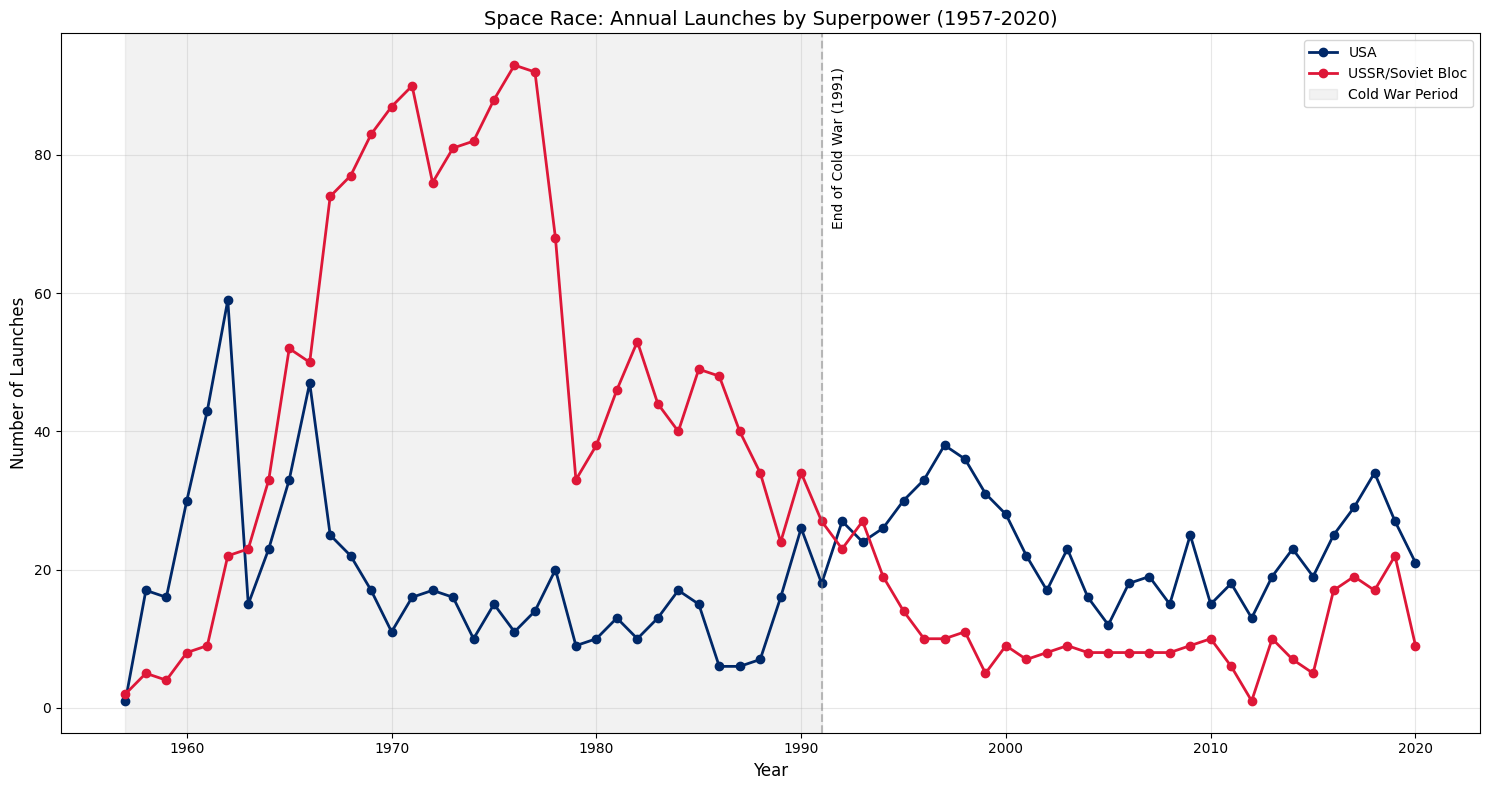

Launch Statistics:

Cold War Period (1957-1991):
USA:
  Total launches: 644
  Average per year: 18.4
  Peak year: 1962.0 (59 launches)
USSR/Soviet Bloc:
  Total launches: 1,709
  Average per year: 48.8
  Peak year: 1976.0 (93 launches)

Post-Cold War Period (1992-2020):
USA:
  Total launches: 683
  Average per year: 23.6
  Peak year: 1997.0 (38 launches)
USSR/Soviet Bloc:
  Total launches: 324
  Average per year: 11.2
  Peak year: 1993.0 (27 launches)


In [ ]:
# Create DataFrame with launch years and superpower categories
yearly_launches = df_data.copy()
yearly_launches['Year'] = pd.to_datetime(yearly_launches['Date']).dt.year

# Filter for just USA and USSR/Soviet Bloc launches
yearly_comparison = yearly_launches[yearly_launches['Superpower'].isin(['USA', 'USSR/Soviet Bloc'])]

# Create pivot table for launches by year and superpower
launches_by_year = pd.pivot_table(
    data=yearly_comparison,
    index='Year',
    columns='Superpower',
    aggfunc='size',
    fill_value=0
)

# Create the plot
plt.figure(figsize=(15, 8))

# Plot each superpower's launches
plt.plot(launches_by_year.index, launches_by_year['USA'], 
        color='#002868', label='USA', linewidth=2, marker='o')
plt.plot(launches_by_year.index, launches_by_year['USSR/Soviet Bloc'], 
        color='#DE1738', label='USSR/Soviet Bloc', linewidth=2, marker='o')

# Add shaded area for Cold War period (1957-1991)
plt.axvspan(1957, 1991, color='gray', alpha=0.1, label='Cold War Period')

plt.title('Space Race: Annual Launches by Superpower (1957-2020)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Add vertical line for end of Cold War
plt.axvline(x=1991, color='gray', linestyle='--', alpha=0.5)
plt.text(1991.5, plt.ylim()[1]*0.95, 'End of Cold War (1991)', 
         rotation=90, verticalalignment='top')

plt.tight_layout()
plt.show()

# Print statistics for different periods
print("Launch Statistics:")
print("\nCold War Period (1957-1991):")
cold_war = launches_by_year.loc[1957:1991]
for power in ['USA', 'USSR/Soviet Bloc']:
    total = cold_war[power].sum()
    avg = cold_war[power].mean()
    max_year = cold_war[power].idxmax()
    max_launches = cold_war[power].max()
    print(f"{power}:")
    print(f"  Total launches: {total:,}")
    print(f"  Average per year: {avg:.1f}")
    print(f"  Peak year: {max_year} ({max_launches} launches)")

print("\nPost-Cold War Period (1992-2020):")
post_war = launches_by_year.loc[1992:]
for power in ['USA', 'USSR/Soviet Bloc']:
    total = post_war[power].sum()
    avg = post_war[power].mean()
    max_year = post_war[power].idxmax()
    max_launches = post_war[power].max()
    print(f"{power}:")
    print(f"  Total launches: {total:,}")
    print(f"  Average per year: {avg:.1f}")
    print(f"  Peak year: {max_year} ({max_launches} launches)")

## Chart the Total Number of Mission Failures Year on Year.

In [29]:
df_data['Datetime_parsed'] = pd.to_datetime(df_data['Datetime'], errors='coerce')
df_data['Year'] = df_data['Datetime_parsed'].dt.year

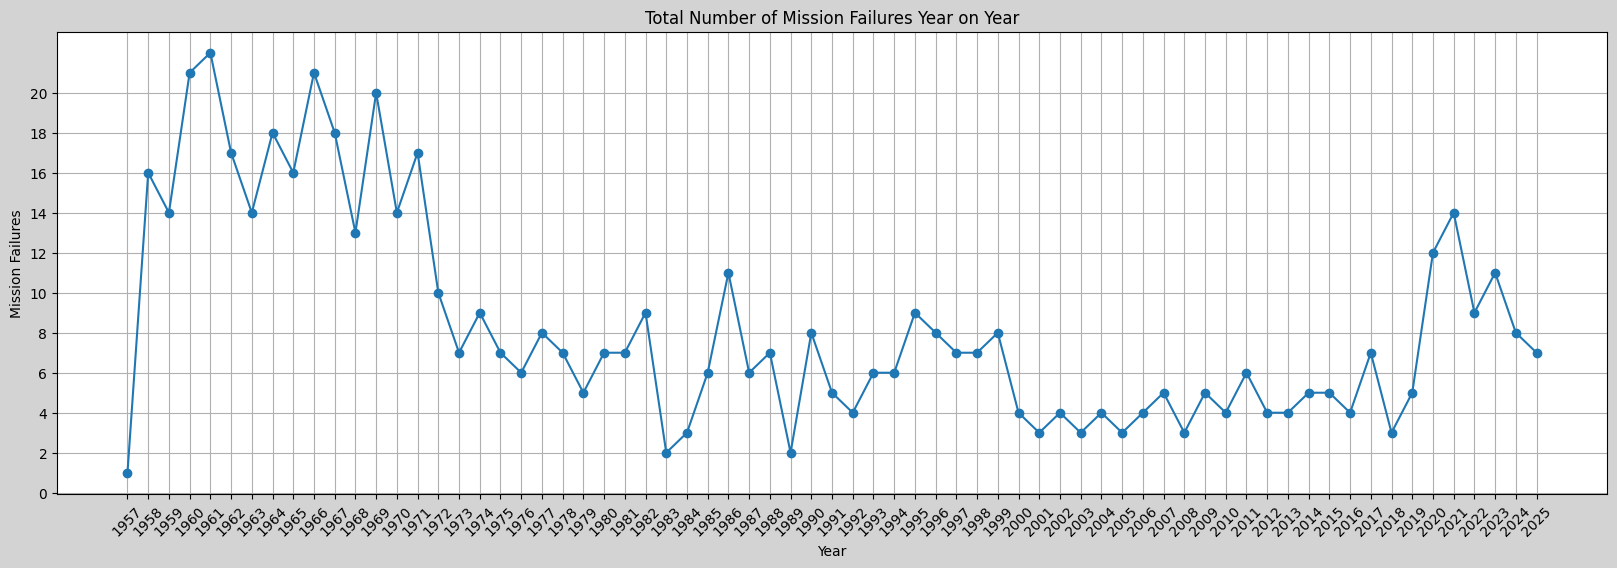

In [40]:

# Create DataFrame with failures by year
df_data['Year'] = pd.to_datetime(df_data['Datetime'], errors='coerce').dt.year
failures = df_data[df_data['Mission_status'].str.lower().str.contains('fail', na=False)]
mission_failures_year_on_year = failures.groupby('Year').size().reset_index(name='Total')

# Create the line plot
plt.figure(figsize=(20, 6), facecolor='lightgray')
plt.plot(mission_failures_year_on_year['Year'], mission_failures_year_on_year['Total'], marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Mission Failures')
plt.title('Total Number of Mission Failures Year on Year')
plt.xticks(mission_failures_year_on_year['Year'], rotation=45)
plt.yticks(range(0, 21, 2))
plt.grid(True)
plt.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

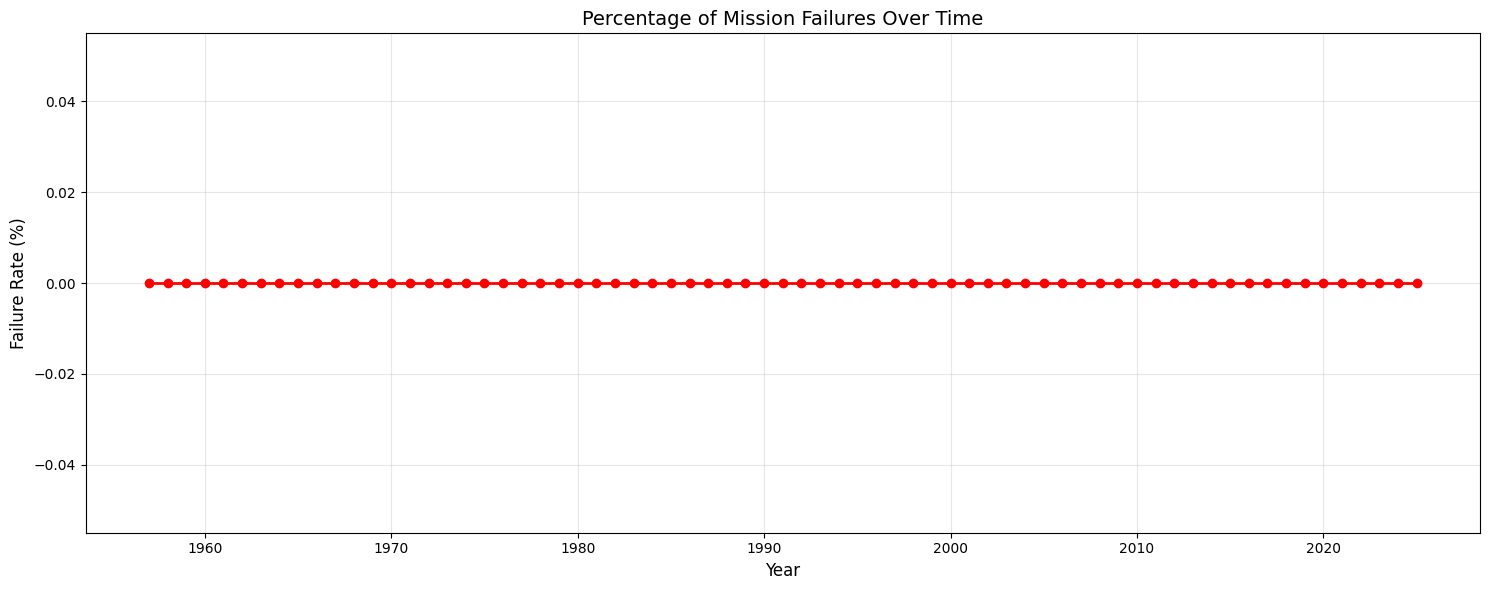

Average failure rate: 0.00%
Highest failure rate: 0.00% in 1957.0
Lowest failure rate: 0.00% in 1957.0


In [42]:
# Calculate year-by-year failure percentage
# Use the correct column name for mission status
status_col = 'Mission Status' if 'Mission Status' in df_data.columns else 'Status'

df_data['Year'] = pd.to_datetime(df_data['Datetime'], errors='coerce').dt.year
failures = df_data[df_data[status_col].str.lower().str.contains('fail', na=False)]

# Count launches and failures per year
launches_per_year = df_data['Year'].value_counts().sort_index()
failures_per_year = failures['Year'].value_counts().sort_index()

# Calculate percentage
failure_pct = (failures_per_year / launches_per_year * 100).fillna(0)

# Plot
plt.figure(figsize=(15, 6))
plt.plot(failure_pct.index, failure_pct.values, marker='o', color='red', linewidth=2)
plt.title('Percentage of Mission Failures Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Failure Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some summary stats
print(f"Average failure rate: {failure_pct.mean():.2f}%")
print(f"Highest failure rate: {failure_pct.max():.2f}% in {failure_pct.idxmax()}")
print(f"Lowest failure rate: {failure_pct.min():.2f}% in {failure_pct.idxmin()}")

### Section above needs to be revised. Results are flat.

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [57]:
top_country_per_year = df_data.groupby([df_data['Datetime'].dt.year.rename('Year'), 'Location', 'Mission_status']).size().reset_index(name='Launch Count')
top_country_launches_per_year = top_country_per_year.groupby(['Year', 'Location'])['Launch Count'].sum().reset_index(name='Launch Count')
top_country_launches_per_year = top_country_launches_per_year.loc[top_country_launches_per_year.groupby('Year')['Launch Count'].idxmax()]

fig = px.bar(top_country_launches_per_year, x="Year", y="Launch Count", color='Location', title='Lead Country in Total Launches')
fig.update_xaxes(dtick=1)
fig.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [53]:
# ...existing code...
df_data['Datetime'] = pd.to_datetime(df_data['Datetime'], errors='coerce')
organization_lead_launch = df_data.groupby([df_data['Datetime'].dt.year.rename('Year'), 'Organisation']).size().reset_index(name='Launch Count')
# ...existing code...
organization_lead_launch = organization_lead_launch.loc[organization_lead_launch.groupby('Year')['Launch Count'].idxmax()]

fig = px.bar(organization_lead_launch, x="Year", y="Launch Count", color='Organisation', title='Lead Organization in Total Launches')
fig.update_xaxes(dtick=1)
fig.show()